**Importing the Required Libraries**

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from scipy.cluster.hierarchy import dendrogram, linkage

import dash
from dash import Dash, html, dcc
from jupyter_dash import JupyterDash
from dash.dependencies import Input, Output

**Load and Visualise Data Spread **

In [33]:
path = 'DataVisu Project.sql.csv'
df = pd.read_csv(path) # Load csv into a dataframe

print('='*90)
print(df.head()) #visualise the first 5 rows

# Visualise data distribution and data summary
print('='*90)
print(df.describe())

print('='*90)
print(df.info())

  CONTROLLER_ERROR_CODE  CONTROLLERTEMPERATUREPUMP  BATTERYCURRENTPUMP  \
0                 56,66                        9.1                85.0   
1           56,64,65,66                       15.6                 0.0   
2           56,64,65,66                       15.7                 0.0   
3           56,64,65,66                       16.1                 0.0   
4                    55                       16.6                 0.0   

   MOTORTEMPERATUREREAR  BATTERYLOWESTCELLVOLTAGE  MOTORTORQUEFR  \
0                   4.0                     3.839          -0.46   
1                  13.4                     3.924           0.00   
2                  13.4                     3.924           0.00   
3                  13.4                     3.924           0.00   
4                  13.4                     3.924           0.00   

   MOTORRPMPUMP  BATTERYARRAYCURRENT  BATTERYCURRENTFR  BATTERYCURRENTREAR  \
0          -2.0                -59.0               1.3              

**Observations:**
Each feature has a different count ranging from 2240 to 3130 (many null values) and varying range for different features. Hence the need for Data Cleaning and Normalisation in the preprocessing phase. Also, the CONTROLLER_ERROR_CODE is a vector with multiple error codes. This will also be split up into it's individual columns

**Data Preprocessing**

In [34]:
df = df[df['CONTROLLER_ERROR_CODE'].str.isnumeric()].dropna() #remove rows with multiple errors

# Filter dataset to the top 10 most frequent error codes to ensure robust training
top_10_errors = df['CONTROLLER_ERROR_CODE'].value_counts().nlargest(5).index
print(f"Top 10 Individual Error Codes: {list(top_10_errors)}")

df_filtered = df[df['CONTROLLER_ERROR_CODE'].isin(top_10_errors)].copy()

Top 10 Individual Error Codes: ['29', '92', '58', '39', '69']


Observation: Rows with multi variables cause poor performamnce

Oversampling classes to match majority size: 166


/var/folders/kv/3rmr8md14wqg2zwj44f8kk5c0000gn/T/ipykernel_37166/1417324840.py:6: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



Correlation matrix visualization generated.

Dropping 15 correlated columns: ['CONTROLLERTEMPERATUREFR', 'BATTERYPOWERFR', 'BATTERYSYSTEMHIGHTEMPERATURE', 'MOTORTEMPERATUREFL', 'BATTERYHIGHESTCELLVOLTAGE', 'BATTERYPOWERFL', 'BATTERYSYSTEMLOWTEMPERATURE', 'MOTORTEMPERATUREPUMP', 'BATTERYCURRENTFL', 'MOTORRPMFR', 'MOTORTEMPERATUREFR', 'CONTROLLERTEMPERATUREREAR', 'MOTORPOWERFR', 'MOTORRPMFL', 'CONTROLLERTEMPERATUREFL']


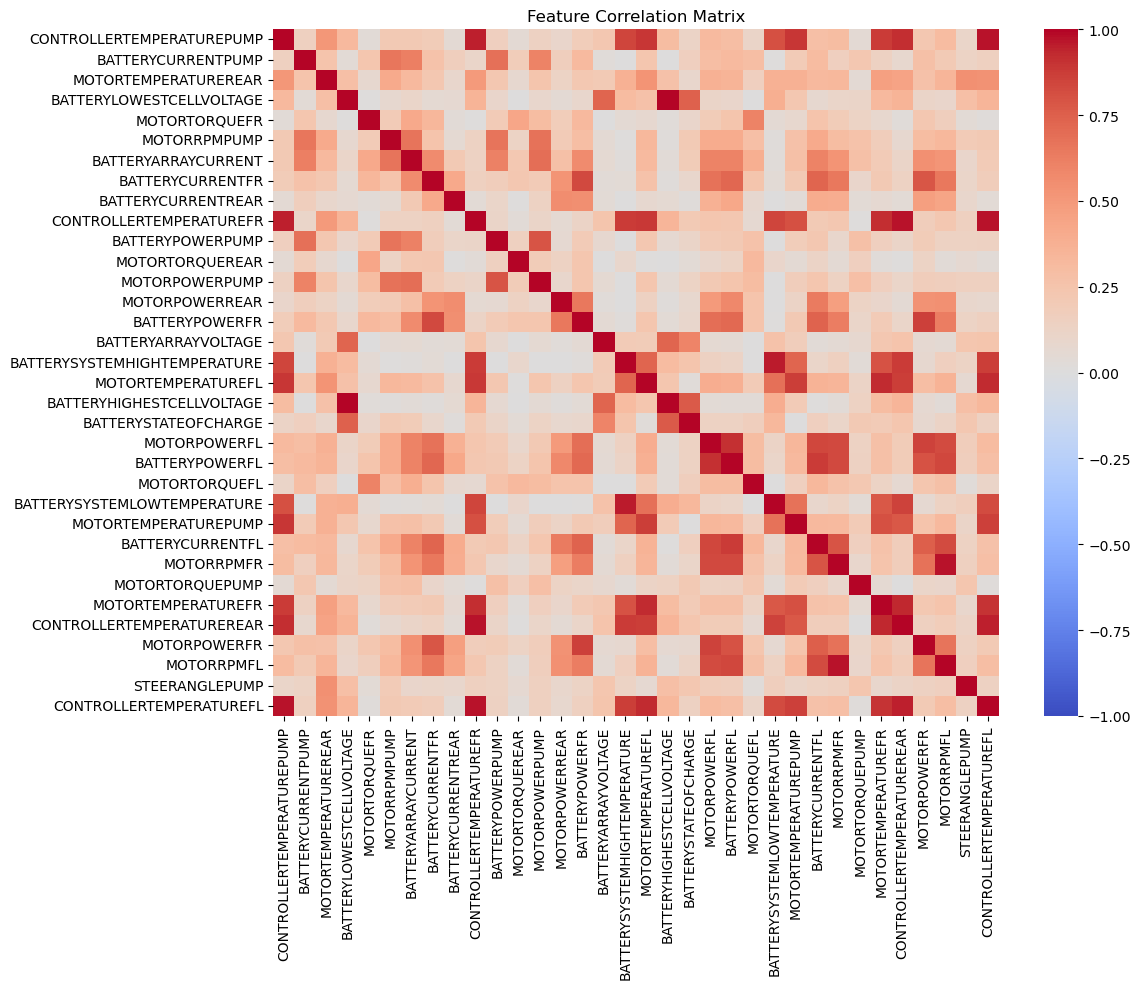

In [35]:
# Balancing Data (Oversampling Minorities)
max_class_size = df_filtered['CONTROLLER_ERROR_CODE'].value_counts().max()
print(f"Oversampling classes to match majority size: {max_class_size}")

# Fixed Deprecation Warning by adding include_groups=False
df_balanced = df_filtered.groupby('CONTROLLER_ERROR_CODE', group_keys=False).apply(
    lambda x: x.sample(max_class_size, replace=True, random_state=42),
    include_groups=True
).reset_index(drop=True)

# Step F: Prepare Feature Matrix
X = df_balanced.drop(columns=['CONTROLLER_ERROR_CODE'])
y = df_balanced['CONTROLLER_ERROR_CODE']

# Create a DataFrame for correlation calculation
X_df = pd.DataFrame(X, columns=X.columns)
corr_matrix = X_df.corr().abs()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png')


print("Correlation matrix visualization generated.")
# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation > 0.85
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
print(f"\nDropping {len(to_drop)} correlated columns: {to_drop}")

# Drop the correlated features
X_reduced = X_df.drop(columns=to_drop)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced)

# Encode Targets
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [53]:
df_balanced['CONTROLLER_ERROR_CODE'].value_counts()

CONTROLLER_ERROR_CODE
29    166
39    166
58    166
69    166
92    166
Name: count, dtype: int64

In [36]:
# Model Execution
k = 5

# -- K-Means --
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
ari_kmeans = adjusted_rand_score(y_encoded, kmeans_labels)

# -- Agglomerative (Hierarchical) --
agglo = AgglomerativeClustering(n_clusters=k, linkage='ward')
agglo_labels = agglo.fit_predict(X_scaled)
ari_agglo = adjusted_rand_score(y_encoded, agglo_labels)

# -- Gaussian Mixture Models (GMM) --
gmm = GaussianMixture(n_components=k, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)
ari_gmm = adjusted_rand_score(y_encoded, gmm_labels)

# -- Supervised Baseline (Random Forest) --
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.3, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

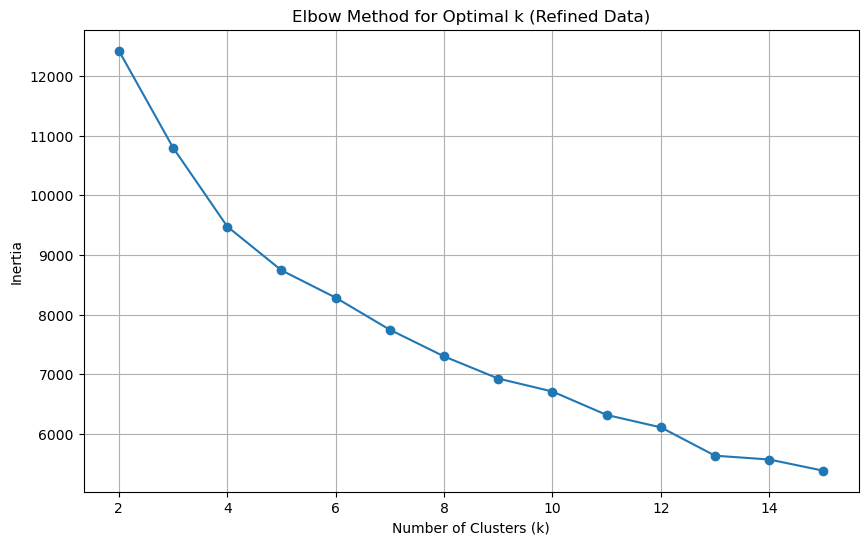

In [37]:
# Generate Elbow Chart (k=2 to 15)

inertia = []
k_range = range(2, 16)
for k_val in k_range:
    km = KMeans(n_clusters=k_val, random_state=42, n_init=5)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal k (Refined Data)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.savefig('elbow_plot_refined.png')


In [39]:
# 6. Output Results
# ----------------------------------------------
print(f"Top 10 Individual Error Codes: {list(top_10_errors)}")
print(f"\nClustering Results with k={k}:")
print(f"1. K-Means ARI: {ari_kmeans:.4f}")
print(f"2. Agglomerative ARI: {ari_agglo:.4f}")
print(f"3. GMM ARI: {ari_gmm:.4f}")

Top 10 Individual Error Codes: ['29', '92', '58', '39', '69']

Clustering Results with k=5:
1. K-Means ARI: 0.2095
2. Agglomerative ARI: 0.2910
3. GMM ARI: 0.1986


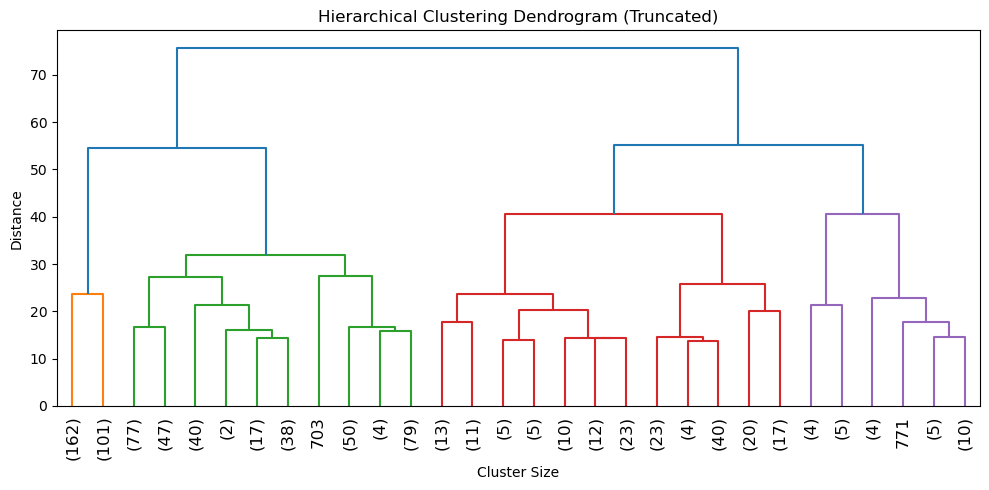

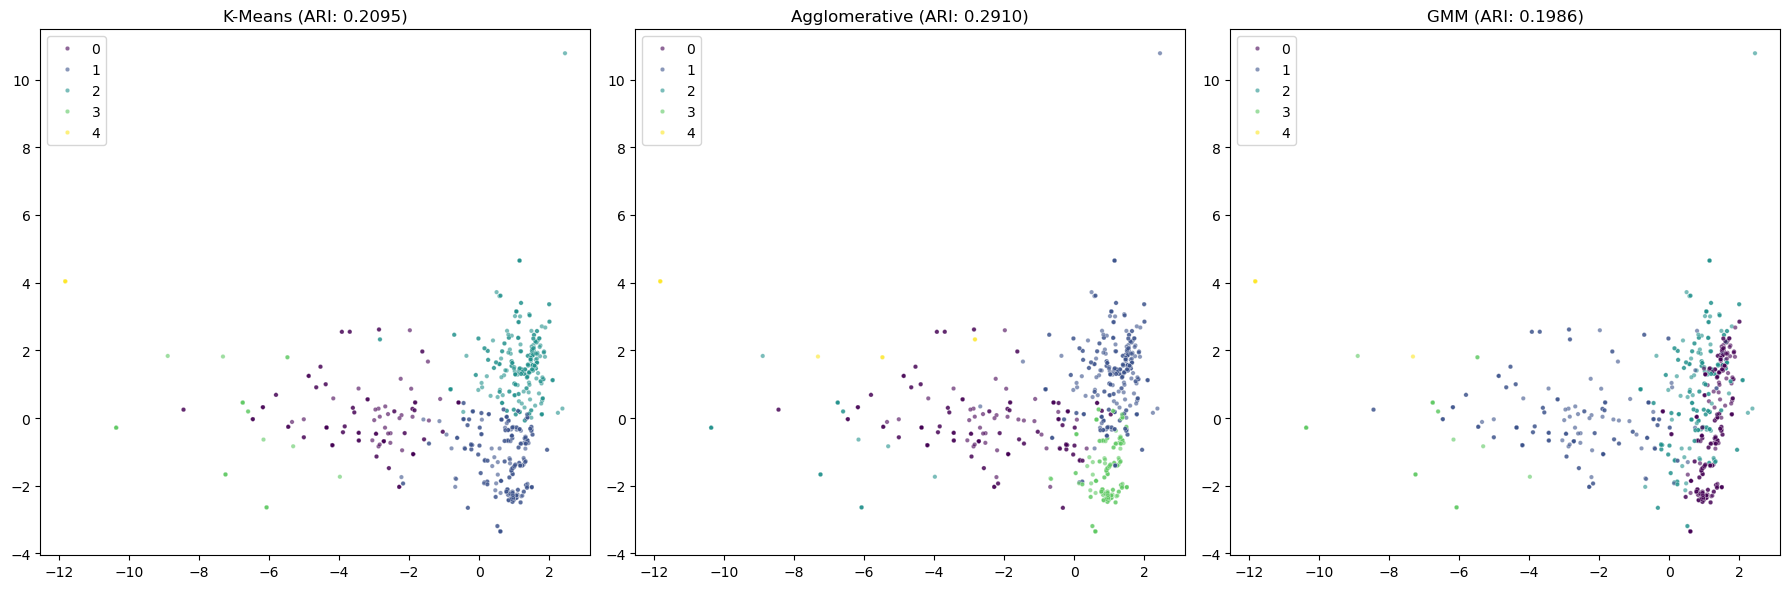

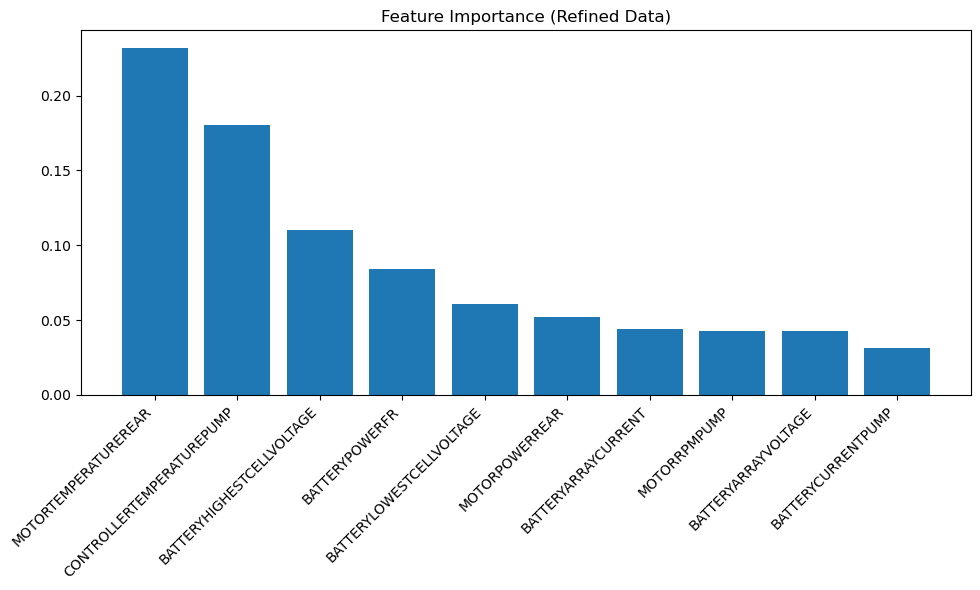

In [40]:
# Visualizations

# Dendrogram (Hierarchical)
plt.figure(figsize=(10, 5))
plt.title('Hierarchical Clustering Dendrogram (Truncated)')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
Z = linkage(X_scaled, method='ward')
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=12., show_contracted=False)
plt.tight_layout()
plt.savefig('dendrogram_refined.png')

# Cluster Comparison
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# K-Means
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='viridis', s=10, ax=axes[0], alpha=0.6)
axes[0].set_title(f'K-Means (ARI: {ari_kmeans:.4f})')
# Agglomerative
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=agglo_labels, palette='viridis', s=10, ax=axes[1], alpha=0.6)
axes[1].set_title(f'Agglomerative (ARI: {ari_agglo:.4f})')
# GMM
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=gmm_labels, palette='viridis', s=10, ax=axes[2], alpha=0.6)
axes[2].set_title(f'GMM (ARI: {ari_gmm:.4f})')
plt.tight_layout()
plt.savefig('clustering_comparison_refined.png')

# Feature Importance
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns
plt.figure(figsize=(10, 6))
plt.title("Feature Importance (Refined Data)")
plt.bar(range(10), importances[indices[:10]], align="center")
plt.xticks(range(10), feature_names[indices[:10]], rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance_refined.png')

In [41]:
# 5. Output Results
print("Refined Preprocessing Results:")
print(f"Top 10 Individual Error Codes: {list(top_10_errors)}")
print(f"K-Means ARI: {ari_kmeans:.4f}")
print(f"Agglomerative ARI: {ari_agglo:.4f}")
print(f"GMM ARI: {ari_gmm:.4f}")
print("\nRandom Forest Classification Report (Refined):")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_]))

Refined Preprocessing Results:
Top 10 Individual Error Codes: ['29', '92', '58', '39', '69']
K-Means ARI: 0.2095
Agglomerative ARI: 0.2910
GMM ARI: 0.1986

Random Forest Classification Report (Refined):
              precision    recall  f1-score   support

          29       1.00      0.98      0.99        53
          39       0.96      1.00      0.98        45
          58       0.94      0.98      0.96        48
          69       1.00      0.98      0.99        50
          92       0.96      0.92      0.94        53

    accuracy                           0.97       249
   macro avg       0.97      0.97      0.97       249
weighted avg       0.97      0.97      0.97       249



In [42]:
X_reduced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 830 entries, 0 to 829
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CONTROLLERTEMPERATUREPUMP  830 non-null    float64
 1   BATTERYCURRENTPUMP         830 non-null    float64
 2   MOTORTEMPERATUREREAR       830 non-null    float64
 3   BATTERYLOWESTCELLVOLTAGE   830 non-null    float64
 4   MOTORTORQUEFR              830 non-null    float64
 5   MOTORRPMPUMP               830 non-null    float64
 6   BATTERYARRAYCURRENT        830 non-null    float64
 7   BATTERYCURRENTFR           830 non-null    float64
 8   BATTERYCURRENTREAR         830 non-null    float64
 9   BATTERYPOWERPUMP           830 non-null    float64
 10  MOTORTORQUEREAR            830 non-null    float64
 11  MOTORPOWERPUMP             830 non-null    float64
 12  MOTORPOWERREAR             830 non-null    float64
 13  BATTERYARRAYVOLTAGE        830 non-null    float64

**DATA PREPARATION**

In [44]:
# Project data into 2D for visualization
components = pca.fit_transform(X_scaled)

df_vis = pd.DataFrame(data=components, columns=['PC1', 'PC2'])
df_vis['Ground_Truth'] = le.inverse_transform(y_encoded)
df_vis['KMeans_Label'] = kmeans_labels
df_vis['Agglo_Label'] = agglo_labels
df_vis['GMM_Label'] = gmm_labels

# Adding back original sensor data (unscaled) for the Parallel Coordinates plot
features_to_plot = ['MOTORTEMPERATUREREAR', 'CONTROLLERTEMPERATUREPUMP', 'BATTERYHIGHESTCELLVOLTAGE']
for col in features_to_plot:
    matching_cols = [c for c in X_reduced.columns if col in c]
    if matching_cols:
        df_vis[col] = X_reduced[matching_cols[0]].values

**DASHBOARD LAYOUT**

In [45]:
external_stylesheets = ['https://codepen.io/chriddyp/pen/bWLwgP.css']
app = Dash(__name__, external_stylesheets=external_stylesheets)

app.layout = html.Div([
    # --- Header ---
    html.Div([
        html.H2("ETMFL Predictive Maintenance Dashboard", style={'textAlign': 'center', 'marginBottom': '10px'}),
        html.P(f"Comparing Unsupervised Models (k={k})", style={'textAlign': 'center', 'color': '#666'})
    ], className='row'),

    # Controls Row
    html.Div([
            html.Div([
                html.Label("Select Algorithm:", style={'fontWeight': 'bold'}),
                dcc.Dropdown(
                    id='algo-dropdown',
                    options=[
                        {'label': 'Agglomerative (Best Performer)', 'value': 'Agglo_Label'},
                        {'label': 'K-Means', 'value': 'KMeans_Label'},
                        {'label': 'Gaussian Mixture (GMM)', 'value': 'GMM_Label'}
                    ],
                    value='Agglo_Label',
                    clearable=False
                )
            ], className='four columns', style={'offset': '4'})
        ], className='row', style={'padding': '20px', 'backgroundColor': '#f9f9f9', 'borderBottom': '1px solid #ddd'}),

    # Row 1: Cluster Analysis 
    html.Div([
        # Left: Scatter Plot
        html.Div([
            dcc.Graph(id='cluster-scatter')
        ], className='six columns'),

        # Right: Confusion Matrix
        html.Div([
            dcc.Graph(id='confusion-heatmap')
        ], className='six columns')
    ], className='row', style={'marginTop': '20px'}),

    # Row 2: Physical Interpretation 
    html.Div([
        html.H4("Operational Profile (Parallel Coordinates)", style={'textAlign': 'center', 'marginTop': '30px'}),
        dcc.Graph(id='parallel-coords')
    ], className='row')
])

@app.callback(
    [Output('cluster-scatter', 'figure'),
     Output('confusion-heatmap', 'figure'),
     Output('parallel-coords', 'figure')],
    [Input('algo-dropdown', 'value')]
)
def update_dashboard(selected_algo):
    # 1. Scatter Plot
    fig_scatter = px.scatter(
        df_vis, x='PC1', y='PC2',
        color=df_vis[selected_algo].astype(str),
        title=f"Cluster Separation (PCA) - {selected_algo}",
        hover_data=['Ground_Truth'],
        color_discrete_sequence=px.colors.qualitative.G10,
        template='plotly_white'
    )
    fig_scatter.update_layout(legend_title_text='Cluster ID')

    # 2. Confusion Heatmap
    conf_matrix = pd.crosstab(df_vis['Ground_Truth'], df_vis[selected_algo])
    # Normalize for better color contrast (optional)
    conf_matrix_norm = conf_matrix.div(conf_matrix.sum(axis=1), axis=0)
    
    fig_heatmap = go.Figure(data=go.Heatmap(
        z=conf_matrix.values,
        x=conf_matrix.columns,
        y=conf_matrix.index,
        colorscale='Blues',
        text=conf_matrix.values,
        texttemplate="%{text}",
        hoverongaps=False
    ))
    fig_heatmap.update_layout(
        title=f"Confusion Matrix: {selected_algo} vs Ground Truth",
        xaxis_title="Predicted Cluster",
        yaxis_title="Actual Error Code"
    )

    # Parallel Coordinates
    valid_features = [col for col in features_to_plot if col in df_vis.columns]
    
    if valid_features:
        cluster_profile = df_vis.groupby(selected_algo)[valid_features].mean().reset_index()
        fig_parcoords = px.parallel_coordinates(
            cluster_profile,
            color=selected_algo,
            dimensions=valid_features,
            title=f"Mean Sensor Readings by Cluster ({selected_algo})",
            color_continuous_scale=px.colors.diverging.Tealrose
        )
    else:
        fig_parcoords = go.Figure().add_annotation(text="Selected features not found in dataset", showarrow=False)

    return fig_scatter, fig_heatmap, fig_parcoords


# 5. RUN SERVER
if __name__ == '__main__':
    # Mode='inline' runs it inside the notebook cell
    app.run(host="localhost",port=8052)

**CALLBACKS**

In [ ]:
1. error correlation
2. pca visualisation
3. input to model